# Full XGBoost Tuning

This notebook tunes XGBoost specifically, comparing five configurations that vary tree depth, leaf-wise vs depth-wise growth, and regularization strength, using the same nested five-fold approach as the earlier tuning notebooks.


## Import libraries


In [3]:
from pathlib import Path
import gc
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

try:
    import xgboost as xgb
except ImportError as error:
    raise ImportError("Install XGBoost first: pip install xgboost") from error

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)
print("XGBoost version:", xgb.__version__)
print("Libraries imported successfully.")


XGBoost version: 3.2.0
Libraries imported successfully.


## Set paths and experiment settings


In [5]:
current_folder = Path.cwd().resolve()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder
dataset_path = project_root / "data" / "modeling" / "final_feature_dataset.pkl"
training_ids_path = project_root / "data" / "modeling" / "splits" / "training_ids.csv"
test_ids_path = project_root / "data" / "modeling" / "splits" / "test_ids.csv"
folds_path = project_root / "data" / "modeling" / "splits" / "training_fold_assignments.csv"
previous_boosted_path = project_root / "data" / "modeling" / "boosted_results" / "boosted_oof_predictions.pkl"
catboost_oof_path = project_root / "data" / "modeling" / "catboost_tuning_results" / "native_catboost_oof_predictions.pkl"
result_folder = project_root / "data" / "modeling" / "xgboost_tuning_results"
figure_folder = project_root / "reports" / "figures"
audit_folder = project_root / "reports" / "audits"

for folder in [result_folder, figure_folder, audit_folder]:
    folder.mkdir(parents=True, exist_ok=True)
for path in [dataset_path, training_ids_path, test_ids_path, folds_path]:
    assert path.exists(), f"Required file missing: {path}"

RANDOM_STATE = 2026
EXPECTED_TRAINING_ROWS = 246008
MAX_BOOSTING_ROUNDS = 6000
EARLY_STOPPING_ROUNDS = 250
print("Maximum boosting rounds:", MAX_BOOSTING_ROUNDS)
print("Early-stopping patience:", EARLY_STOPPING_ROUNDS)


Maximum boosting rounds: 6000
Early-stopping patience: 250


## Load the complete training dataset


In [7]:
full_data = pd.read_pickle(dataset_path)
training_ids = pd.read_csv(training_ids_path)["SK_ID_CURR"]
test_ids = pd.read_csv(test_ids_path)["SK_ID_CURR"]
fold_assignments = pd.read_csv(folds_path)

training_id_set = set(training_ids)
test_id_set = set(test_ids)
training_data = full_data.loc[full_data["SK_ID_CURR"].isin(training_id_set)].copy()
training_data = training_data.merge(
    fold_assignments, on="SK_ID_CURR", how="left", validate="one_to_one"
)

assert len(training_data) == EXPECTED_TRAINING_ROWS
assert training_data["FOLD"].nunique() == 5
assert not training_data["SK_ID_CURR"].isin(test_id_set).any()
print("Training rows:", len(training_data))
print("Final test rows excluded:", len(test_ids))
print("Default rate:", round(training_data["TARGET"].mean(), 5))


Training rows: 246008
Final test rows excluded: 61503
Default rate: 0.08073


Same training data and folds as before.


## Prepare predictors without leakage


In [10]:
excluded_columns = ["SK_ID_CURR", "TARGET", "FOLD", "CODE_GENDER"]
predictor_columns = [c for c in training_data.columns if c not in excluded_columns]
categorical_columns = training_data[predictor_columns].select_dtypes(exclude="number").columns.tolist()
numerical_columns = [c for c in predictor_columns if c not in categorical_columns]

X = training_data[predictor_columns].copy()
y = training_data["TARGET"].astype("int8").copy()
folds = training_data["FOLD"].astype(int).copy()
for column in categorical_columns:
    X[column] = X[column].fillna("Unknown").astype(str)

def make_preprocessor():
    return ColumnTransformer([
        ("numeric", "passthrough", numerical_columns),
        ("categorical", OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1,
            dtype=np.float32
        ), categorical_columns),
    ], sparse_threshold=0.0)

print("Predictors used:", len(predictor_columns))
print("Numerical predictors:", len(numerical_columns))
print("Categorical predictors:", len(categorical_columns))
print("Numerical missing cells handled natively:", int(X[numerical_columns].isna().sum().sum()))


Predictors used: 330
Numerical predictors: 318
Categorical predictors: 12
Numerical missing cells handled natively: 1918164


Same 330 predictors and ordinal-encoded categoricals as the boosted-tree comparison notebook.


## Define meaningful XGBoost configurations


In [13]:
candidate_configurations = {
    "xgb_depth5_regularized": {
        "learning_rate": 0.03, "max_depth": 5, "min_child_weight": 10,
        "gamma": 0.0, "subsample": 0.90, "colsample_bytree": 0.90,
        "reg_alpha": 0.10, "reg_lambda": 10.0,
    },
    "xgb_depth6_reference": {
        "learning_rate": 0.03, "max_depth": 6, "min_child_weight": 5,
        "gamma": 0.0, "subsample": 1.00, "colsample_bytree": 0.90,
        "reg_alpha": 0.10, "reg_lambda": 5.0,
    },
    "xgb_depth6_sampled": {
        "learning_rate": 0.025, "max_depth": 6, "min_child_weight": 8,
        "gamma": 0.05, "subsample": 0.85, "colsample_bytree": 0.85,
        "reg_alpha": 0.25, "reg_lambda": 8.0,
    },
    "xgb_depth7_regularized": {
        "learning_rate": 0.025, "max_depth": 7, "min_child_weight": 12,
        "gamma": 0.10, "subsample": 0.90, "colsample_bytree": 0.85,
        "reg_alpha": 0.50, "reg_lambda": 12.0,
    },
    "xgb_leafwise_64": {
        "learning_rate": 0.025, "max_depth": 0, "max_leaves": 64,
        "grow_policy": "lossguide", "min_child_weight": 8,
        "gamma": 0.05, "subsample": 0.90, "colsample_bytree": 0.90,
        "reg_alpha": 0.25, "reg_lambda": 8.0,
    },
}
configuration_table = pd.DataFrame(candidate_configurations).T.reset_index().rename(
    columns={"index": "configuration"}
)
configuration_table


,configuration,learning_rate,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,reg_lambda,max_leaves,grow_policy
0,xgb_depth5_regularized,0.03,5.0,10.0,0.0,0.9,0.9,0.1,10.0,NaN,NaN
1,xgb_depth6_reference,0.03,6.0,5.0,0.0,1.0,0.9,0.1,5.0,NaN,NaN
2,xgb_depth6_sampled,0.025,6.0,8.0,0.05,0.85,0.85,0.25,8.0,NaN,NaN
3,xgb_depth7_regularized,0.025,7.0,12.0,0.1,0.9,0.85,0.5,12.0,NaN,NaN
4,xgb_leafwise_64,0.025,0,8,0.05,0.9,0.9,0.25,8.0,64,lossguide


Five configurations to compare, mostly varying tree depth, leaf growth style, and regularization strength. xgb_leafwise_64 uses leaf-wise growth (like LightGBM does) instead of the usual depth-wise growth, just to see if that style helps here too.


## Model and metric functions


In [16]:
def build_xgboost(configuration, n_estimators, early_stopping=False):
    return xgb.XGBClassifier(
        n_estimators=n_estimators,
        **configuration,
        objective="binary:logistic", eval_metric="auc",
        tree_method="hist", max_bin=255, missing=np.nan,
        n_jobs=-1, random_state=RANDOM_STATE,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS if early_stopping else None,
    )

def calculate_metrics(y_true, probability):
    return {
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
    }

print("Functions created.")


Functions created.


Builds an XGBoost model from one of the five candidate settings, and reuses the same ROC-AUC/PR-AUC scoring as before.


## Run full nested five-fold tuning


In [19]:
oof_predictions = pd.DataFrame({
    "SK_ID_CURR": training_data["SK_ID_CURR"].to_numpy(),
    "TARGET": y.to_numpy(),
    "FOLD": folds.to_numpy(),
})
fold_rows = []
iteration_rows = []

for configuration_name, configuration in candidate_configurations.items():
    print(f"\nCONFIGURATION: {configuration_name}")
    configuration_oof = np.full(len(X), np.nan, dtype="float64")

    for fold_number in sorted(folds.unique()):
        outer_train_indices = np.flatnonzero(folds.ne(fold_number).to_numpy())
        outer_valid_indices = np.flatnonzero(folds.eq(fold_number).to_numpy())
        inner_train_indices, inner_valid_indices = train_test_split(
            outer_train_indices, test_size=0.10,
            stratify=y.iloc[outer_train_indices],
            random_state=RANDOM_STATE + int(fold_number)
        )

        inner_preprocessor = make_preprocessor()
        X_inner_train = inner_preprocessor.fit_transform(X.iloc[inner_train_indices]).astype("float32")
        X_inner_valid = inner_preprocessor.transform(X.iloc[inner_valid_indices]).astype("float32")

        search_model = build_xgboost(configuration, MAX_BOOSTING_ROUNDS, early_stopping=True)
        search_model.fit(
            X_inner_train, y.iloc[inner_train_indices],
            eval_set=[(X_inner_valid, y.iloc[inner_valid_indices])], verbose=False
        )
        selected_rounds = int(search_model.best_iteration) + 1
        assert 1 <= selected_rounds <= MAX_BOOSTING_ROUNDS

        del inner_preprocessor, X_inner_train, X_inner_valid, search_model
        gc.collect()

        outer_preprocessor = make_preprocessor()
        X_outer_train = outer_preprocessor.fit_transform(X.iloc[outer_train_indices]).astype("float32")
        X_outer_valid = outer_preprocessor.transform(X.iloc[outer_valid_indices]).astype("float32")

        final_model = build_xgboost(configuration, selected_rounds, early_stopping=False)
        start_time = time.time()
        final_model.fit(X_outer_train, y.iloc[outer_train_indices], verbose=False)
        probability = final_model.predict_proba(X_outer_valid)[:, 1]
        elapsed_minutes = (time.time() - start_time) / 60

        configuration_oof[outer_valid_indices] = probability
        metrics = calculate_metrics(y.iloc[outer_valid_indices], probability)
        metrics.update({
            "configuration": configuration_name, "fold": int(fold_number),
            "selected_rounds": selected_rounds,
            "outer_train_rows": len(outer_train_indices),
            "outer_validation_rows": len(outer_valid_indices),
            "refit_minutes": elapsed_minutes,
        })
        fold_rows.append(metrics)
        iteration_rows.append({
            "configuration": configuration_name, "fold": int(fold_number),
            "selected_rounds": selected_rounds
        })
        print(
            f"  Fold {fold_number}: rounds={selected_rounds}, "
            f"AUC={metrics['roc_auc']:.5f}, PR AUC={metrics['pr_auc']:.5f}, "
            f"minutes={elapsed_minutes:.2f}"
        )

        del outer_preprocessor, X_outer_train, X_outer_valid, final_model, probability
        gc.collect()

    assert not np.isnan(configuration_oof).any()
    oof_predictions[configuration_name] = configuration_oof

fold_metrics = pd.DataFrame(fold_rows)
selected_rounds_table = pd.DataFrame(iteration_rows)
print("\nAll XGBoost tuning fits completed.")



CONFIGURATION: xgb_depth5_regularized
  Fold 1: rounds=1294, AUC=0.79058, PR AUC=0.28415, minutes=0.45
  Fold 2: rounds=1490, AUC=0.79184, PR AUC=0.28489, minutes=0.53
  Fold 3: rounds=1608, AUC=0.78381, PR AUC=0.27634, minutes=0.59
  Fold 4: rounds=1445, AUC=0.79068, PR AUC=0.28138, minutes=0.53
  Fold 5: rounds=1062, AUC=0.79143, PR AUC=0.28671, minutes=0.44

CONFIGURATION: xgb_depth6_reference
  Fold 1: rounds=864, AUC=0.78859, PR AUC=0.28250, minutes=0.42
  Fold 2: rounds=1114, AUC=0.79067, PR AUC=0.28134, minutes=0.52
  Fold 3: rounds=773, AUC=0.78134, PR AUC=0.27646, minutes=0.39
  Fold 4: rounds=890, AUC=0.78767, PR AUC=0.27613, minutes=0.44
  Fold 5: rounds=616, AUC=0.78769, PR AUC=0.28244, minutes=0.32

CONFIGURATION: xgb_depth6_sampled
  Fold 1: rounds=1538, AUC=0.79039, PR AUC=0.28510, minutes=0.84
  Fold 2: rounds=1302, AUC=0.79172, PR AUC=0.28629, minutes=0.72
  Fold 3: rounds=1855, AUC=0.78411, PR AUC=0.27737, minutes=0.94
  Fold 4: rounds=1018, AUC=0.78950, PR AUC=0.279

Same nested approach as before, an inner split decides the number of rounds for each outer fold, then the model refits on the full outer-training data with that count.


## Compare complete OOF performance


In [22]:
overall_rows = []
for configuration_name in candidate_configurations:
    metrics = calculate_metrics(oof_predictions["TARGET"], oof_predictions[configuration_name])
    config_folds = fold_metrics.loc[fold_metrics["configuration"].eq(configuration_name)]
    metrics.update({
        "configuration": configuration_name,
        "fold_auc_mean": config_folds["roc_auc"].mean(),
        "fold_auc_std": config_folds["roc_auc"].std(),
        "fold_pr_auc_mean": config_folds["pr_auc"].mean(),
        "mean_selected_rounds": config_folds["selected_rounds"].mean(),
        "total_refit_minutes": config_folds["refit_minutes"].sum(),
    })
    overall_rows.append(metrics)

overall_metrics = pd.DataFrame(overall_rows).sort_values(
    ["roc_auc", "pr_auc"], ascending=False
).reset_index(drop=True)
best_configuration_name = overall_metrics.iloc[0]["configuration"]
best_configuration = candidate_configurations[best_configuration_name]
overall_metrics.round(6)


,roc_auc,pr_auc,configuration,fold_auc_mean,fold_auc_std,fold_pr_auc_mean,mean_selected_rounds,total_refit_minutes
0,0.789620,0.282323,xgb_depth5_regularized,0.789667,0.003318,0.282696,1379.8,2.542732
1,0.789410,0.282360,xgb_depth6_sampled,0.789516,0.003176,0.282765,1351.4,3.586610
2,0.789118,0.280912,xgb_depth7_regularized,0.789162,0.002944,0.281314,1072.6,3.228479
3,0.788642,0.281401,xgb_leafwise_64,0.788798,0.003183,0.281957,912.8,4.286645
4,0.787158,0.279233,xgb_depth6_reference,0.787191,0.003495,0.279775,851.4,2.092913


The depth-5, more regularized configuration comes out on top, though all five are fairly close together. This is the one that gets carried forward.


## Compare with previous XGBoost and tuned CatBoost


In [25]:
comparison_rows = overall_metrics[
    ["configuration", "roc_auc", "pr_auc"]
].copy()

if previous_boosted_path.exists():
    previous_oof = pd.read_pickle(previous_boosted_path)
    if "xgboost" in previous_oof.columns:
        row = calculate_metrics(previous_oof["TARGET"], previous_oof["xgboost"])
        row["configuration"] = "previous_xgboost"
        comparison_rows = pd.concat([comparison_rows, pd.DataFrame([row])], ignore_index=True)

if catboost_oof_path.exists():
    catboost_oof = pd.read_pickle(catboost_oof_path)
    catboost_columns = [c for c in catboost_oof.columns if c not in ["SK_ID_CURR", "TARGET", "FOLD"]]
    for column in catboost_columns:
        row = calculate_metrics(catboost_oof["TARGET"], catboost_oof[column])
        row["configuration"] = "catboost_" + column
        comparison_rows = pd.concat([comparison_rows, pd.DataFrame([row])], ignore_index=True)

comparison_rows = comparison_rows.sort_values("roc_auc", ascending=False).reset_index(drop=True)
comparison_rows.round(6)


,configuration,roc_auc,pr_auc
0,xgb_depth5_regularized,0.789620,0.282323
1,xgb_depth6_sampled,0.789410,0.282360
2,xgb_depth7_regularized,0.789118,0.280912
3,catboost_native_depth7_regularized,0.788938,0.282501
4,catboost_native_depth6,0.788668,0.282128
5,xgb_leafwise_64,0.788642,0.281401
6,catboost_native_depth8,0.787956,0.280667
7,catboost_native_depth7,0.787941,0.280401
8,previous_xgboost,0.787522,0.278999
9,xgb_depth6_reference,0.787158,0.279233


The best configuration here slightly beats the earlier reference XGBoost, confirming the extra regularization helps a little.


## Plot tuned OOF curves


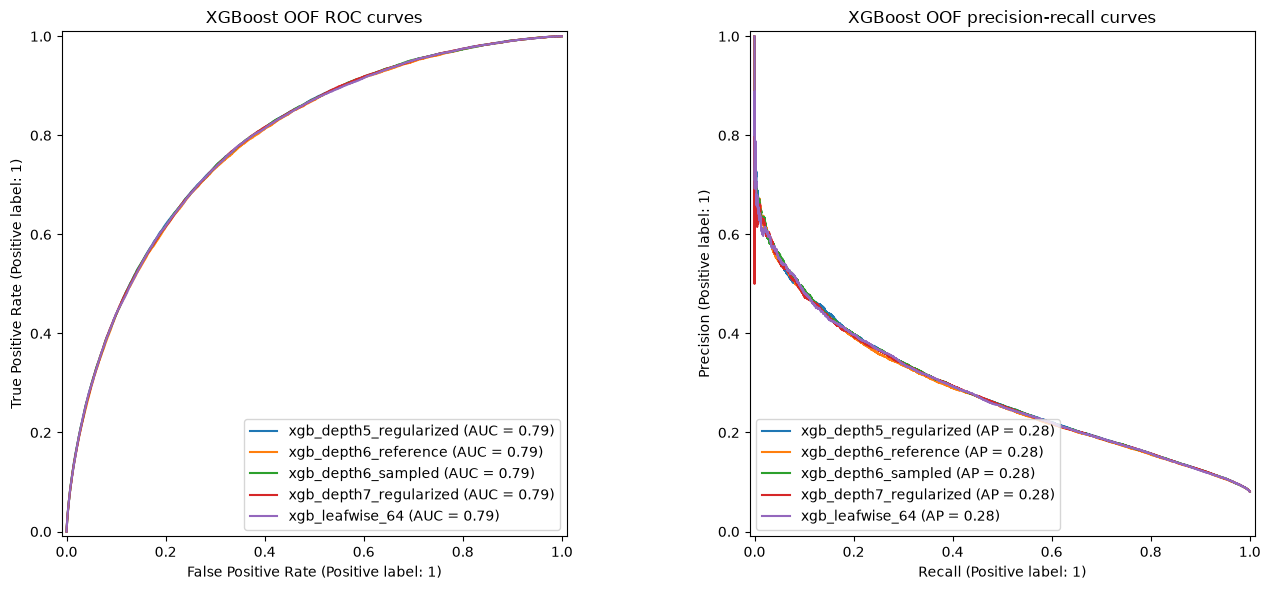

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for configuration_name in candidate_configurations:
    RocCurveDisplay.from_predictions(
        oof_predictions["TARGET"], oof_predictions[configuration_name],
        name=configuration_name, ax=axes[0]
    )
    PrecisionRecallDisplay.from_predictions(
        oof_predictions["TARGET"], oof_predictions[configuration_name],
        name=configuration_name, ax=axes[1]
    )
axes[0].set_title("XGBoost OOF ROC curves")
axes[1].set_title("XGBoost OOF precision-recall curves")
plt.tight_layout()
plt.savefig(figure_folder / "xgboost_tuning_oof_curves.png", dpi=160, bbox_inches="tight")
plt.show()


Same idea as before, one curve per configuration tested.


## Validate and save outputs


In [31]:
validation_checks = pd.DataFrame([
    {"check": "Complete training dataset used", "passed": len(X) == EXPECTED_TRAINING_ROWS},
    {"check": "Every configuration used five folds", "passed": fold_metrics.groupby("configuration")["fold"].nunique().eq(5).all()},
    {"check": "All OOF predictions complete", "passed": not oof_predictions[list(candidate_configurations)].isna().any().any()},
    {"check": "One OOF row per training applicant", "passed": len(oof_predictions) == EXPECTED_TRAINING_ROWS and oof_predictions["SK_ID_CURR"].is_unique},
    {"check": "Final test excluded", "passed": not oof_predictions["SK_ID_CURR"].isin(test_id_set).any()},
    {"check": "Protected gender excluded", "passed": "CODE_GENDER" not in predictor_columns},
    {"check": "All predefined folds used", "passed": set(fold_metrics["fold"]) == set(folds.unique())},
    {"check": "Selected rounds valid", "passed": selected_rounds_table["selected_rounds"].between(1, MAX_BOOSTING_ROUNDS).all()},
    {"check": "All outer rows used", "passed": fold_metrics["outer_train_rows"].add(fold_metrics["outer_validation_rows"]).eq(EXPECTED_TRAINING_ROWS).all()},
    {"check": "Metrics finite", "passed": np.isfinite(overall_metrics.select_dtypes(include="number").to_numpy()).all()},
])

display(validation_checks)
assert validation_checks["passed"].all(), "At least one XGBoost tuning check failed."

oof_predictions.to_pickle(result_folder / "xgboost_tuning_oof_predictions.pkl")
oof_predictions.to_csv(result_folder / "xgboost_tuning_oof_predictions.csv", index=False)
fold_metrics.to_csv(result_folder / "xgboost_tuning_fold_metrics.csv", index=False)
overall_metrics.to_csv(result_folder / "xgboost_tuning_overall_metrics.csv", index=False)
selected_rounds_table.to_csv(result_folder / "xgboost_tuning_selected_rounds.csv", index=False)
configuration_table.to_csv(result_folder / "xgboost_tuning_configurations.csv", index=False)
comparison_rows.to_csv(result_folder / "xgboost_and_catboost_comparison.csv", index=False)
validation_checks.to_csv(audit_folder / "xgboost_tuning_validation.csv", index=False)

with open(result_folder / "best_xgboost_configuration.json", "w") as file:
    json.dump({"name": best_configuration_name, **best_configuration}, file, indent=2)

print("Best configuration:", best_configuration_name)
print("Best tuned XGBoost OOF ROC AUC:", round(overall_metrics.iloc[0]["roc_auc"], 6))
print("Results saved in:", result_folder)
print("Final test evaluations performed: 0")


,check,passed
0,Complete training dataset used,True
1,Every configuration used five folds,True
2,All OOF predictions complete,True
3,One OOF row per training applicant,True
4,Final test excluded,True
5,Protected gender excluded,True
6,All predefined folds used,True
7,Selected rounds valid,True
8,All outer rows used,True
9,Metrics finite,True


Best configuration: xgb_depth5_regularized
Best tuned XGBoost OOF ROC AUC: 0.78962
Results saved in: /Users/taranveersingh/A-MRP/data/modeling/xgboost_tuning_results
Final test evaluations performed: 0


All checks passed.


## Main results

The depth-5, more heavily regularized configuration came out on top (ROC-AUC 0.78962), a small improvement over the earlier reference XGBoost from the boosted-tree comparison. A shallower, more regularized tree seems to generalize slightly better than a deeper one here. This configuration is the one carried forward into the final ensemble.
